In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Importing Required Libraries

Importing Python libraries required for:
- data analysis
- data visualization
- machine learning workflow

In [5]:
# Data manipulation and analysis
import pandas as pd  
# Numerical computations
import numpy as np  

# Data visualization
import matplotlib.pyplot as plt 
import seaborn as sns

# Loading Titanic Dataset

Loading:
- training dataset
- testing dataset

from Kaggle input directory.


In [6]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [7]:
# Displays first 5 rows of training dataset
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Returns dataset dimensions as (rows, columns)
train.shape

(891, 12)

# Dataset Information

Analyzing:
- column names
- data types
- non-null counts
- missing values

In [9]:
# Displays complete dataset information
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Missing Values Analysis

Checking how many missing values are present
in each column of the dataset.

In [10]:
# Counts missing values in each column
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Survival Distribution

Visualizing the number of passengers who:
- survived
- did not survive

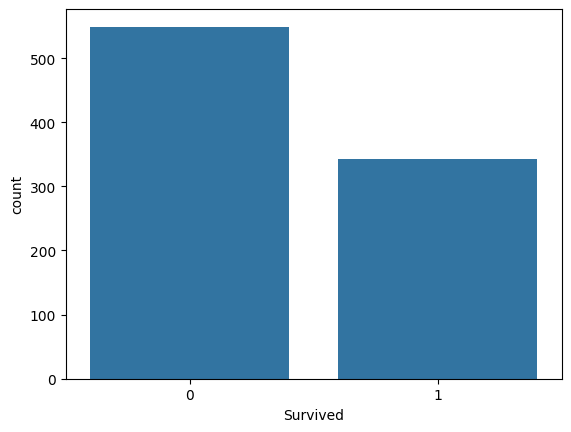

In [11]:
# Creates countplot for survival distribution
sns.countplot(x='Survived', data=train)

# Displays graph
plt.show()

# Survival Rate Based on Gender

Analyzing whether gender affected
passenger survival probability.

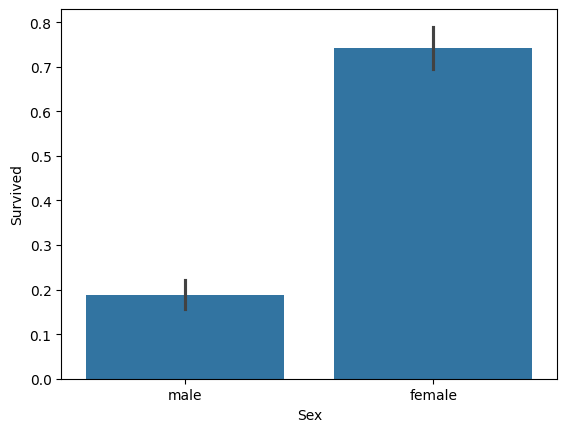

In [12]:
# Creates barplot for survival probability by gender
sns.barplot(x='Sex', y='Survived', data=train)

# Displays graph
plt.show()

# Passenger Class Distribution

Visualizing the distribution of passengers
across different ticket classes.

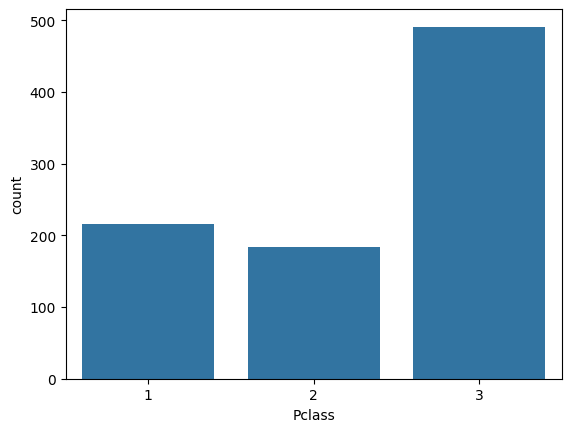

In [13]:
# Countplot for passenger classes
sns.countplot(x='Pclass', data=train)

# Display graph
plt.show()

# Survival Probability Based on Passenger Class

Analyzing how passenger class affected
survival probability during the disaster.

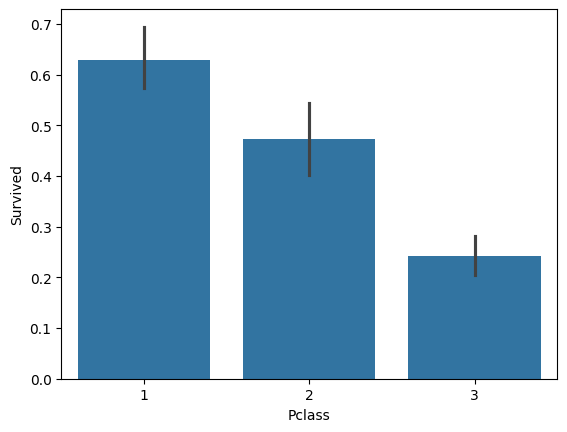

In [30]:
# Barplot for survival probability by passenger class
sns.barplot(x='Pclass', y='Survived', data=train)

# Display graph
plt.show()

# Age Distribution Analysis

Visualizing passenger age distribution
to understand demographic spread.

# Dropping Unnecessary Columns

Removing columns with excessive missing values
or columns not useful for the initial model.

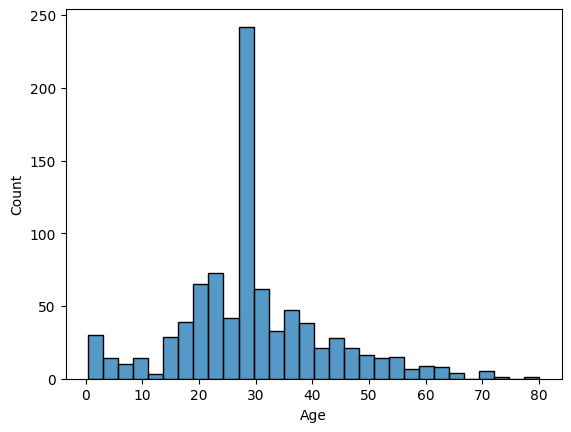

In [31]:
# Histogram for passenger ages
sns.histplot(train['Age'])

# Display graph
plt.show()

In [14]:
# Dropping Cabin column from training dataset
train.drop(columns=['Cabin'], inplace=True)

# Dropping Cabin column from testing dataset
test.drop(columns=['Cabin'], inplace=True)

# Handling Missing Age Values

Replacing missing age values using
the median age of passengers.


In [15]:
# Filling missing Age values using median imputation
train['Age'] = train['Age'].fillna(train['Age'].median())

# Doing same for test dataset
test['Age'] = test['Age'].fillna(test['Age'].median())

# Missing Value Imputation for Embarked Feature

Handling missing categorical values in the Embarked column
using mode imputation based on the most frequent category.

In [16]:
# Filling missing Embarked values using mode imputation
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# Verifying Missing Values

Checking dataset again after preprocessing
to confirm missing values are handled.

In [17]:
# Checking remaining missing values
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Categorical Feature Encoding - Sex Feature

Applying label encoding to convert categorical
gender values into numerical representations
for machine learning model compatibility.

In [18]:
# Importing LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Creating encoder object
le = LabelEncoder()

# Encoding Sex column in training dataset
train['Sex'] = le.fit_transform(train['Sex'])

# Encoding Sex column in testing dataset
test['Sex'] = le.transform(test['Sex'])

# Categorical Feature Encoding - Embarked Feature

Encoding embarkation categories into
numerical values using label encoding.

In [19]:
# Encoding Embarked column in training dataset
train['Embarked'] = le.fit_transform(train['Embarked'])

# Encoding Embarked column in testing dataset
test['Embarked'] = le.transform(test['Embarked'])

# Verifying Encoded Features

Previewing dataset after categorical encoding
to confirm successful numerical transformation.

In [20]:
# Displaying first 5 rows after preprocessing
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


# Correlation Heatmap Analysis

Visualizing correlations between numerical features
to identify relationships affecting survival prediction.

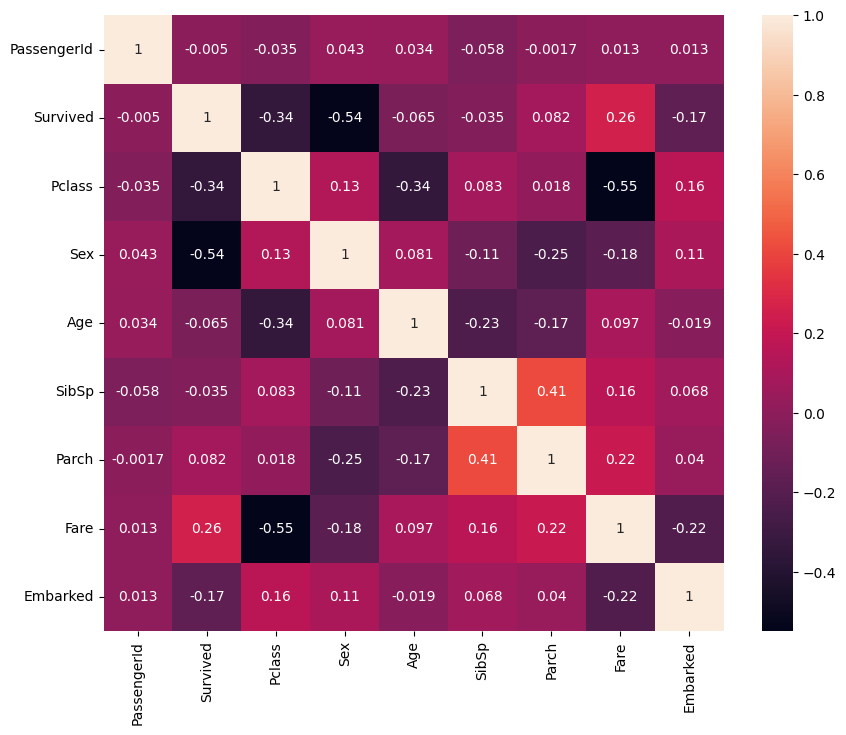

In [32]:
# Setting figure size
plt.figure(figsize=(10,8))

# Generating correlation heatmap
sns.heatmap(train.corr(numeric_only=True), annot=True)

# Display graph
plt.show()

# Feature Selection

Selecting relevant features for training
the machine learning classification model.

Target variable:
- Survived

Selected input features:
- Pclass
- Sex
- Age
- Fare
- Embarked

In [21]:
# Selecting input features
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']

# Creating feature matrix
X = train[features]

# Creating target variable
y = train['Survived']

# Train-Test Split

Splitting dataset into:
- training data
- validation data

to evaluate model performance on unseen samples.

In [22]:
# Importing train_test_split
from sklearn.model_selection import train_test_split

# Splitting dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest Classification Model

Training a Random Forest classifier
for passenger survival prediction.

In [23]:
# Importing Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Creating model
model = RandomForestClassifier(random_state=42)

# Training model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Model Prediction

Generating survival predictions
on validation dataset.

In [24]:
# Predicting on validation data
predictions = model.predict(X_val)

# Model Evaluation

Evaluating classification performance
using accuracy score.

In [25]:
# Importing accuracy metric
from sklearn.metrics import accuracy_score

# Calculating model accuracy
accuracy = accuracy_score(y_val, predictions)

# Displaying accuracy
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7877094972067039


# Preparing Test Dataset Features

Selecting the same input features from the
testing dataset for final survival prediction.

In [26]:
# Selecting features from testing dataset
X_test = test[features]


# Generating Predictions

Using trained Random Forest model
to predict passenger survival outcomes
on unseen test data.

In [27]:
# Predicting survival on test dataset
test_predictions = model.predict(X_test)

# Creating Kaggle Submission File

Creating submission dataframe containing:
- PassengerId
- predicted survival labels

In [28]:
# Creating submission dataframe
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

# Previewing submission file
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1


# Exporting Submission File

Saving predictions as CSV file
for Kaggle competition submission.

In [29]:
# Exporting submission file
submission.to_csv('submission.csv', index=False)